## Reward-Return Regression (RRR)

The **Reward-Return Regression** is a framework that reduces Reinforcement Learning to a supervised learning problem. It bridges the gap between short-term planning and long-term value estimation using an "algorithmic shell" composed of two models and a rollout.

### 1. The Core Architecture
The agent evaluates an action by decomposing the expected total value into two distinct temporal parts:

* **The Look-Ahead (Reward Model $M_R$):** A supervised regressor trained to predict the immediate reward $r$ for a given $(s, a)$. During inference, we "roll out" this model (or use the environment physics) for a finite horizon $H$.
* **The Tail Correction (Return Model $M_G$):** A supervised regressor trained to predict the cumulative discounted return $G$ from a given $(s, a)$ to the end of the episode. This model "corrects" the truncated rollout by providing a statistical estimate of all future rewards beyond the horizon $H$.

**The Scoring Formula:**
$$Q(s_0, a) \approx \sum_{t=0}^{H-1} \gamma^t R(s_t, a_t) + \gamma^H G(s_H, a_H)$$



---

### 2. Training Routines

To implement this successfully, we transition from a static "offline" approach to an "iterative" refinement loop.

#### A. Offline Training Routine
This is the baseline phase where the models learn the "rules of the world" from existing data without further interaction.
1.  **Data Collection:** A logging policy (often random) interacts with the environment to create a static buffer of trajectories.
2.  **Labeling:** Every $(s, a)$ in the buffer is labeled with its observed immediate reward ($r$) and its Monte Carlo return ($G = \sum \gamma^k r_k$).
3.  **Supervised Learning:** Two black-box regressors are trained. $M_R$ minimizes the error on $r$, and $M_G$ minimizes the error on $G$.
4.  **Limitation:** Performance is capped by the "best" behavior seen in the random data. The models cannot easily generalize to high-reward states they haven't visited.

#### B. Iterative Training Routine
To break the performance ceiling, the agent must actively seek better data to refine its supervised models.
1.  **Initial Seed:** Start with a small amount of random offline data and train the initial $M_R$ and $M_G$.
2.  **Agent-Led Collection:** Use the current HSR agent (with its $H$-step planning) to interact with the environment. Because the planner is better than random, it reaches states with higher returns.
3.  **Dataset Aggregation:** Add these new, "higher-quality" trajectories to the global buffer.
4.  **Retraining:** Retrain the supervised models on the updated buffer. The Return Model $M_G$ now sees examples of high success, allowing it to provide more accurate "Tail Corrections" for the next round of planning.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import gymnasium as gym
import copy

import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

In [2]:
# -------------------------
# Regressor (MLP)
# -------------------------
class SupervisedLearner(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.net(x)


# -------------------------
# Reward-Return Regressor
# -------------------------
class SRLAgent:
    def __init__(self, state_dim, action_dim, gamma=0.99):
        # 1. Predicts instantaneous rewards: r = M_R(s, a)
        self.reward_model = SupervisedLearner(state_dim + 1, 1)
        # 2. Predicts cumulative discounted returns: G = M_G(s, a)
        self.return_model = SupervisedLearner(state_dim + 1, 1)
        
        self.gamma = gamma
        self.action_dim = action_dim

        self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)

    def parameters(self):
        return list(self.reward_model.parameters()) + \
               list(self.return_model.parameters())
    
    def train(self, buffer, steps=10, batch_size=64):
        num_samples = buffer['s'].size(0)
        train_loss = []
        for _ in range(steps):
            indices = torch.randint(0, num_samples, (batch_size,))
            batch = {
                's':      buffer['s'][indices],
                'a':      buffer['a'][indices],
                'r':      buffer['r'][indices],
                's_next': buffer['s_next'][indices],
                'g':      buffer['g'][indices]
            }
            loss = self.train_step(batch)
            train_loss.append(loss)
        return train_loss

    def train_step(self, batch):
        sa = torch.cat([batch['s'], batch['a']], dim=1)
        
        loss_r = nn.MSELoss()(self.reward_model(sa), batch['r'])
        loss_g = nn.MSELoss()(self.return_model(sa), batch['g'])
        
        total_loss = loss_r + loss_g
        self.optimizer.zero_grad()
        total_loss.backward()
        self.optimizer.step()
        return total_loss.item()

    def select_action(self, state, horizon=3, sim_env=None, real_env=None):
        if not sim_env or not real_env:
            raise ValueError("sim_env and real_env must be provided for planning.")
    
        scores = []
        state_t = torch.tensor(state, dtype=torch.float32).view(1, -1)
        for a in range(self.action_dim):
            # Synchronize physics (we use a "simulator" environment to obtain rollouts)
            # Simulator environment in this case is the same as the real environment
            sim_env.unwrapped.state = copy.deepcopy(real_env.unwrapped.state)
            
            q_value = 0
            curr_s_t = state_t
            action_t = torch.tensor([[a]], dtype=torch.float32)
            
            for h in range(horizon):
                # obtain the next state from the simulator environment
                # (question: if we do not have simulator environment, how would we obtain the next state for the rollout)
                next_s, _, term, trunc, _ = sim_env.step(a)

                sa = torch.cat([curr_s_t, action_t], dim=1)

                # compute the instantaneous reward using the supervised reward model and add it to the cumulative reward
                q_value += (self.gamma ** h) * self.reward_model(sa).item()

                curr_s_t = torch.tensor(next_s, dtype=torch.float32).view(1, -1)

                if term or trunc: 
                    break
            
            sa_tail = torch.cat([curr_s_t, action_t], dim=1)
            
            # Use the supervised return Model for the Tail Correction
            q_value += (self.gamma ** horizon) * self.return_model(sa_tail).item()
            scores.append(q_value)
            
        return np.argmax(scores) # pick initial action that led to the highest score

### Data Collection

In [3]:
def collect_offline_data(env_name, num_episodes, gamma=0.99):
    """Collect data from a random policy"""
    env = gym.make(env_name)
    buffer = {'s': [], 'a': [], 'r': [], 's_next': [], 'g': []}

    for _ in range(num_episodes):
        s, _ = env.reset()
        episode = []
        terminated, truncated = False, False
        
        while not (terminated or truncated):
            a = env.action_space.sample()  # Random exploration
            s_next, r, terminated, truncated, _ = env.step(a)
            episode.append((s, a, r, s_next))
            s = s_next
            
        # Compute Returns (G) from end to start
        g_tail = 0
        for s_t, a_t, r_t, sn_t in reversed(episode):
            g_tail = r_t + gamma * g_tail
            buffer['s'].append(s_t)
            buffer['a'].append(a_t)
            buffer['r'].append(r_t)
            buffer['s_next'].append(sn_t)
            buffer['g'].append(g_tail)
            
    # Convert to Tensors
    for k in buffer:
        buffer[k] = torch.tensor(np.array(buffer[k]), dtype=torch.float32)
        if k in ['a', 'r', 'g']: buffer[k] = buffer[k].unsqueeze(1)
    return buffer


def collect_agent_data(agent, env_name, num_episodes, gamma=0.99, epsilon=0.1):
    """Collect data from the current agent instantiation"""
    env = gym.make(env_name)
    sim_env = gym.make(env_name)
    sim_env.reset()
    
    buffer = {'s': [], 'a': [], 'r': [], 's_next': [], 'g': []}

    for _ in range(num_episodes):
        s, _ = env.reset()
        episode = []
        done = False
        
        while not done:
            # Epsilon-greedy exploration to keep data diverse
            if np.random.random() < epsilon:
                a = env.action_space.sample()
            else:
                # Use the planning rollout to pick the action
                a = agent.select_action(s, horizon=3, real_env=env, sim_env=sim_env)
            
            s_next, r, term, trunc, _ = env.step(a)
            episode.append((s, a, r, s_next))
            s = s_next
            done = term or trunc
            
        # Compute Returns (G) from end to start
        g_tail = 0
        for s_t, a_t, r_t, sn_t in reversed(episode):
            g_tail = r_t + gamma * g_tail
            buffer['s'].append(s_t)
            buffer['a'].append(a_t)
            buffer['r'].append(r_t)
            buffer['s_next'].append(sn_t)
            buffer['g'].append(g_tail)
            
    # Convert to Tensors
    for k in buffer:
        buffer[k] = torch.tensor(np.array(buffer[k]), dtype=torch.float32)
        if k in ['a', 'r', 'g']: buffer[k] = buffer[k].unsqueeze(1)
    
    env.close()
    sim_env.close()
    return buffer

### Evaluation

In [4]:
def evaluate(agent, env_name="CartPole-v1", num_seeds=10):
    """In evaluation, we run the agent on several episodes and record the mean/std average return"""
    sim_env = gym.make(env_name)

    all_returns = []
    for seed in range(num_seeds):
        env = gym.make(env_name)
        s, _ = env.reset(seed=seed)

        sim_env.reset(seed=seed)

        total_r = 0
        done = False
        while not done:
            a = agent.select_action(s, horizon=3, real_env=env, sim_env=sim_env)
            s, r, term, trunc, _ = env.step(a)
            total_r += r
            done = term or trunc
        all_returns.append(total_r)
        env.close()
    sim_env.close()
    return np.mean(all_returns), np.std(all_returns)

### Training 

In [11]:
def iterative_training(env_name="CartPole-v1", iterations=10, episodes_per_iter=100):
    state_dim = 4
    action_dim = 2
    
    # Initialize our SRLAgent (The Horizon-Correction Shell)
    agent = SRLAgent(state_dim=state_dim, action_dim=action_dim)
    
    # Start with a small random seed dataset
    print("Collecting Initial Random Seed Data...")
    global_buffer = collect_offline_data(env_name, num_episodes=100)
    
    history = []

    for i in range(iterations):
        print(f"\n--- Iteration {i+1}/{iterations} ---")
        
        # Step A: Train on everything we've seen so far
        # Increase epochs slightly as the buffer grows
        # num_epochs = 500 + (i * 100) 
        # num_epochs = 500
        agent.train(global_buffer, steps=100, batch_size=64)
        # for _ in range(num_epochs):
        #     agent.train_step(global_buffer)
        
        # Step B: Evaluate the current performance
        mean_r, std_r = evaluate(agent, env_name=env_name, num_seeds=10)
        history.append([mean_r, std_r])
        print(f"Current Avg Return: {mean_r:.2f}")

        # Step C: Data Aggregation (The "DAgger" step)
        # Use the CURRENT agent to collect the NEXT batch of data
        print(f"Collecting {episodes_per_iter} episodes using current agent...")
        new_data = collect_agent_data(agent, env_name, episodes_per_iter)
        
        # Append new data to global buffer
        for key in global_buffer:
            global_buffer[key] = torch.cat([global_buffer[key], new_data[key]], dim=0)
            
        print(f"Total samples in buffer: {len(global_buffer['s'])}")

    return agent, history

In [12]:
# --- 3. Run and Plot ---
trained_agent, results = iterative_training(iterations=15)


--- Iteration 1/15 ---
Current Avg Return: 9.40


/Users/ashwindesilva/research/ProspectiveForaging/.venv/lib/python3.11/site-packages/gymnasium/envs/classic_control/cartpole.py:214: UserWarning: WARN: You are calling 'step()' even though this environment has already returned terminated = True. You should always call 'reset()' once you receive 'terminated = True' -- any further steps are undefined behavior.
  logger.warn(


Total samples in buffer: 3189

--- Iteration 2/15 ---
Current Avg Return: 9.40
Total samples in buffer: 6175

--- Iteration 3/15 ---
Current Avg Return: 46.50
Total samples in buffer: 14175

--- Iteration 4/15 ---
Current Avg Return: 20.00
Total samples in buffer: 17127

--- Iteration 5/15 ---
Current Avg Return: 84.30
Total samples in buffer: 24653

--- Iteration 6/15 ---
Current Avg Return: 113.90
Total samples in buffer: 34268

--- Iteration 7/15 ---
Current Avg Return: 232.80
Total samples in buffer: 43360

--- Iteration 8/15 ---
Current Avg Return: 180.10
Total samples in buffer: 58512

--- Iteration 9/15 ---
Current Avg Return: 500.00
Total samples in buffer: 108187

--- Iteration 10/15 ---
Current Avg Return: 472.10
Total samples in buffer: 157004

--- Iteration 11/15 ---
Current Avg Return: 500.00
Total samples in buffer: 205983

--- Iteration 12/15 ---
Current Avg Return: 496.10
Total samples in buffer: 254968

--- Iteration 13/15 ---
Current Avg Return: 499.60
Total samples i

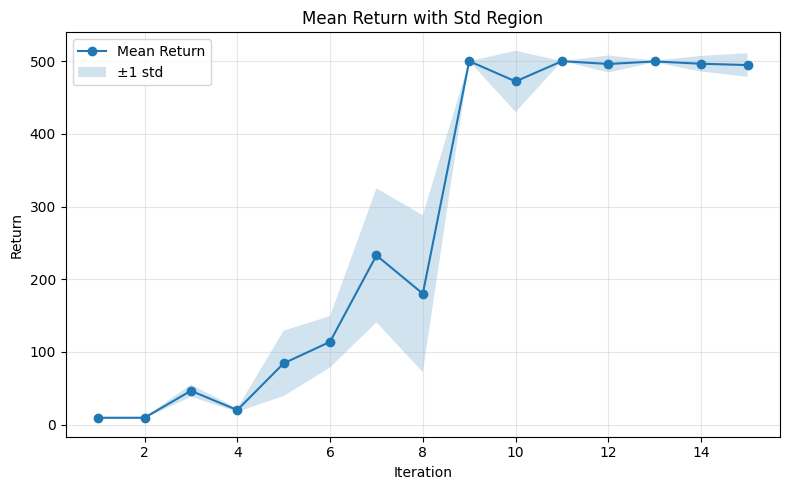

In [13]:
means_r = [m for m, s in results]
stds_r = [s for m, s in results]

iters = list(range(1, len(means_r) + 1))
lower_r = [m - s for m, s in zip(means_r, stds_r)]
upper_r = [m + s for m, s in zip(means_r, stds_r)]

plt.figure(figsize=(8, 5))
plt.plot(iters, means_r, marker='o', label='Mean Return')
plt.fill_between(iters, lower_r, upper_r, alpha=0.2, label='±1 std')
plt.xlabel("Iteration")
plt.ylabel("Return")
plt.title("Mean Return with Std Region")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Visualizing an Episode

In [14]:
def visualize_episode(agent, env_name="CartPole-v1", horizon=3):
    # Set render_mode to rgb_array to capture pixel data
    env = gym.make(env_name, render_mode="rgb_array")
    sim_env = gym.make(env_name)
    
    state, _ = env.reset()
    sim_env.reset()
    
    frames = []
    done = False
    
    while not done:
        # 1. Capture the current frame
        frames.append(env.render())
        
        # 2. Agent selects action (using our horizon-correction shell)
        action = agent.select_action(state, horizon=horizon, 
                                     real_env=env, sim_env=sim_env)
        
        # 3. Step the environment
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.close()
    sim_env.close()

    # --- Animate the frames ---
    fig = plt.figure(figsize=(5, 4))
    ax = plt.gca()
    patch = ax.imshow(frames[0])
    plt.axis('off')

    def animate(i):
        patch.set_data(frames[i])

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50)
    
    # Close the initial plot so it doesn't show up twice
    plt.close()
    
    return HTML(anim.to_jshtml())

In [15]:
html_video = visualize_episode(trained_agent, horizon=3)
html_video

### Discarded